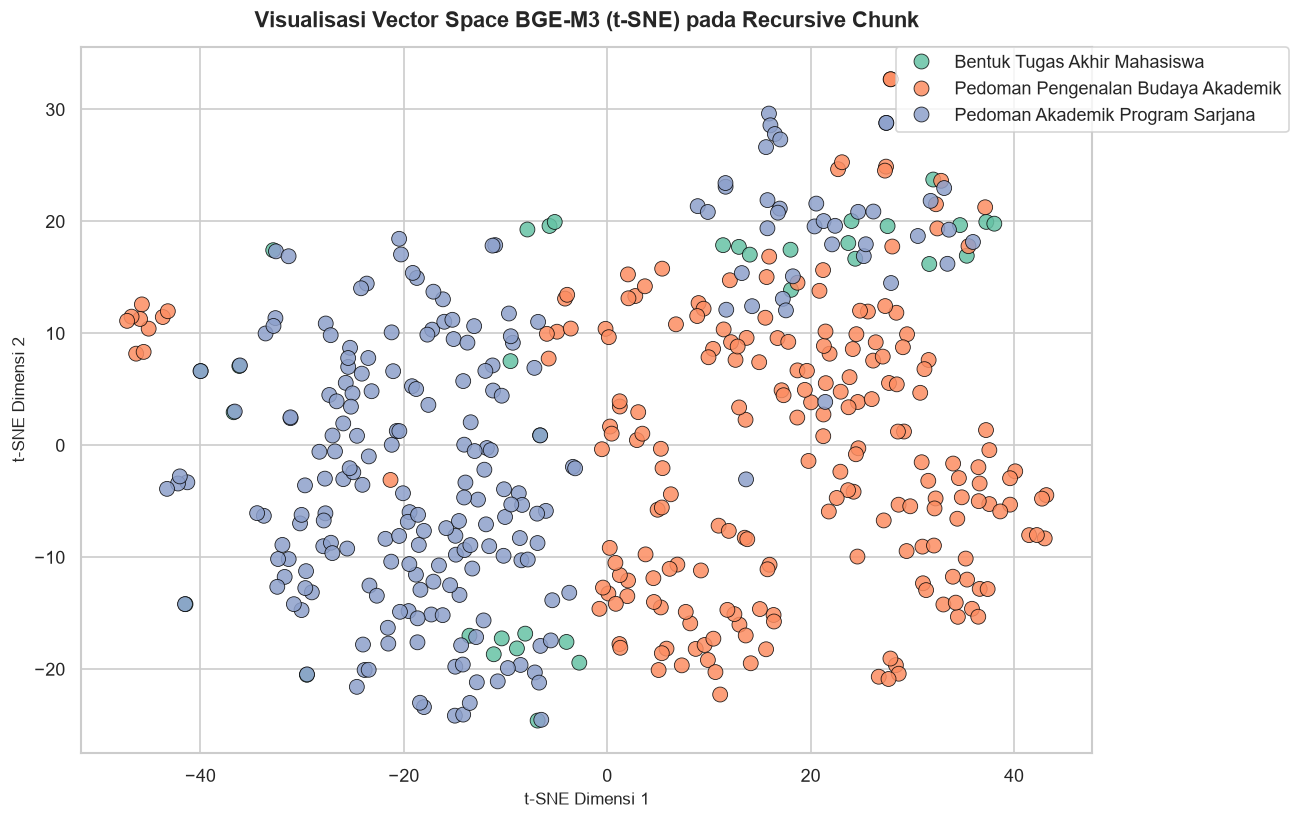

In [14]:
import sys

sys.path.append("../")
from vector_db import vector_db

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE

target_chunk = "recursive-chunk"
data = vector_db.get_vector_db(target_chunk).get(
  include=["embeddings", "metadatas"]
)

embeddings = np.array(data["embeddings"])

categories = []
for meta in data["metadatas"]:
  source_path = meta.get("source", "") if meta else ""

  if "Bentuk_Tugas" in source_path:
    label = "Bentuk Tugas Akhir Mahasiswa"
  elif "pengenalan_budaya" in source_path or "PBAK" in source_path:
    label = "Pedoman Pengenalan Budaya Akademik"
  elif "Pedoman_Akademik" in source_path:
    label = "Pedoman Akademik Program Sarjana"

  categories.append(label)

tsne = TSNE(
  n_components=2,
  perplexity=25,
  random_state=42,
  init="pca",
  learning_rate="auto",
)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(11, 7), dpi=120)
sns.set_theme(style="whitegrid")

sns.scatterplot(
  x=embeddings_2d[:, 0],
  y=embeddings_2d[:, 1],
  hue=categories, 
  palette="Set2", 
  alpha=0.85,
  s=80, 
  edgecolor="black",
  linewidth=0.5,
)

plt.title(
  f"Visualisasi Vector Space BGE-M3 (t-SNE) pada {target_chunk.replace("-", " ").title()}", fontsize=13, fontweight="bold", pad=12
)
plt.xlabel("t-SNE Dimensi 1", fontsize=10)
plt.ylabel("t-SNE Dimensi 2", fontsize=10)

plt.legend(
  bbox_to_anchor=(1, 1),
  loc="upper center",
  borderaxespad=0,
)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model = "bge-m3")

df_test = pd.read_csv("../document/data_test_rag1.csv", sep = ";")
questions, references = [df_test[col].tolist() for col in ["question", "reference"]]

questions_vec = np.array(embeddings.embed_documents(questions))

In [6]:
import numpy as np
import pandas as pd
from langchain_ollama import OllamaEmbeddings

collections_name = ["fixed-chunk", "recursive-chunk", "semantic-chunk"]
embeddings = OllamaEmbeddings(model = "bge-m3")

df_results = pd.read_csv("../result_data/result_data.csv", sep = ";")

def cosine_similarity(vecs_a, vecs_b):
  dot_products = np.sum(vecs_a * vecs_b, axis=1)
  norms_a = np.linalg.norm(vecs_a, axis=1)
  norms_b = np.linalg.norm(vecs_b, axis=1)

  return dot_products / (norms_a * norms_b + 1e-10)

scores = {}
for name in collections_name:
  retrieved_contexts = df_results[f"{name}_retrieved_context"].tolist()

  chunks = [context.split("\n\n") for context in retrieved_contexts]
  top1_contexts = [chunk[0] for chunk in chunks]
  top3_contexts = [chunk[2] for chunk in chunks]

  top1_contexts_vec = np.array(embeddings.embed_documents(top1_contexts))
  top3_contexts_vec = np.array(embeddings.embed_documents(top3_contexts))

  sim_top1 = cosine_similarity(questions_vec, top1_contexts_vec)
  sim_top3 = cosine_similarity(questions_vec, top3_contexts_vec)

  score = (sim_top1 + sim_top3) / 2.0
  scores[name] = score

df_scores = pd.DataFrame(scores)

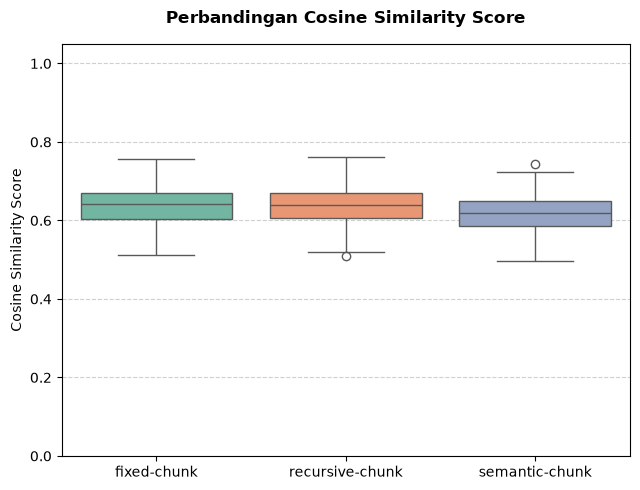

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6.5, 5))

sns.boxplot(
  data=df_scores, 
  palette="Set2",
  meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}
)

plt.title("Perbandingan Cosine Similarity Score", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Cosine Similarity Score", fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()